# SemanticKITTI Traffic Sign 데이터 분석

### 분석 목표

1. SemanticKITTI 데이터셋 구조 및 데이터 형식 분석
2. Traffic Sign 클래스의 데이터 특성 및 공간 분포 분석
3. Traffic Sign 객체의 Point Density와 거리 특성 분석
4. Clustering을 이용한 Traffic Sign 객체 분리
5. DBSCAN과 Voxel Connected Components Clustering 비교
6. BEV 기반 객체 시각화 및 Clustering 결과 확인
7. GT 분석을 기반으로 Bounding Box Filtering 기준 도출
8. Semantic Segmentation 결과를 활용한 Traffic Sign 3D Bounding Box 생성 기반 마련


### 라이브러리 및 기본 설정

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =====================
# CONFIG
# =====================
DATA_ROOT = Path("./../data/semantickitti")
SEQ = "08"

VELODYNE_DIR = DATA_ROOT / "sequences" / SEQ / "velodyne"
LABEL_DIR = DATA_ROOT / "sequences" / SEQ / "labels"

TRAFFIC_SIGN_ID = 81

print("DATA_ROOT   :", DATA_ROOT)
print("SEQ         :", SEQ)
print("VELODYNE_DIR:", VELODYNE_DIR)
print("LABEL_DIR   :", LABEL_DIR)

DATA_ROOT   : ../data/semantickitti
SEQ         : 08
VELODYNE_DIR: ../data/semantickitti/sequences/08/velodyne
LABEL_DIR   : ../data/semantickitti/sequences/08/labels


### 데이터 구조 파악

In [2]:
seq_dir = DATA_ROOT / "sequences" / SEQ

print("sequence directory:", seq_dir)
print("exists:", seq_dir.exists())

if seq_dir.exists():
    for p in sorted(seq_dir.iterdir()):
        print("-", p.name)

sequence directory: ../data/semantickitti/sequences/08
exists: True
- labels
- poses.txt
- velodyne


In [3]:
bin_files = sorted(VELODYNE_DIR.glob("*.bin"))
label_files = sorted(LABEL_DIR.glob("*.label"))

print("point cloud frames:", len(bin_files))
print("label frames      :", len(label_files))

point cloud frames: 4071
label frames      : 4071


##### Point Cloud Data

In [4]:
sample_bin = bin_files[0]

sample_points = np.fromfile(sample_bin, dtype=np.float32).reshape(-1, 4)

print("sample file :", sample_bin.name)
print("points shape:", sample_points.shape)
print("columns     : x, y, z, intensity")

pd.DataFrame(sample_points[:5], columns=["x", "y", "z", "intensity"])

sample file : 000000.bin
points shape: (123389, 4)
columns     : x, y, z, intensity


,x,y,z,intensity
0,62.080463,5.705714,2.316812,0.0
1,59.127041,5.620704,2.216698,0.0
2,59.213177,6.004752,2.220632,0.0
3,59.063961,6.083762,2.215611,0.0
4,60.022522,6.373797,2.249607,0.0


In [5]:
cols = ["x", "y", "z", "intensity"]

stats = {
    c: {
        "min": np.inf,
        "max": -np.inf,
    }
    for c in cols
}

total_points = 0
num_files = 0
bad_files = []

points_per_file = []

for bin_path in bin_files:
    raw = np.fromfile(bin_path, dtype=np.float32)

    if raw.size % 4 != 0:
        bad_files.append((bin_path.name, raw.size))
        continue

    points = raw.reshape(-1, 4)
    num_points = points.shape[0]

    if num_points == 0:
        bad_files.append((bin_path.name, 0))
        continue

    num_files += 1
    total_points += num_points
    points_per_file.append(num_points)

    for i, c in enumerate(cols):
        v = points[:, i]

        stats[c]["min"] = min(stats[c]["min"], float(v.min()))
        stats[c]["max"] = max(stats[c]["max"], float(v.max()))

summary_rows = []

for c in cols:
    min_v = stats[c]["min"]
    max_v = stats[c]["max"]

    summary_rows.append({
        "column": c,
        "min": min_v,
        "max": max_v,
        "range": max_v - min_v,
    })

summary_df = pd.DataFrame(summary_rows)

dataset_info = pd.DataFrame([{
    "num_files": num_files,
    "total_points": total_points,
    "avg_points_per_file": float(np.mean(points_per_file)) if points_per_file else 0.0,
    "min_points_per_file": int(np.min(points_per_file)) if points_per_file else 0,
    "max_points_per_file": int(np.max(points_per_file)) if points_per_file else 0,
}])

print("=== Dataset Info ===")
display(dataset_info)

print("=== XYZ / Intensity Summary ===")
display(summary_df)

if bad_files:
    print("=== Bad Files ===")
    display(pd.DataFrame(bad_files, columns=["file", "raw_float_count"]))

=== Dataset Info ===


,num_files,total_points,avg_points_per_file,min_points_per_file,max_points_per_file
0,4071,499079562,122593.849668,92476,128443


=== XYZ / Intensity Summary ===


,column,min,max,range
0,x,-80.605179,79.997261,160.602440
1,y,-79.997200,79.986008,159.983208
2,z,-30.942255,3.511903,34.454158
3,intensity,0.000000,0.990000,0.990000


##### Label Data

`.label` 파일은 `uint32` 형식이다.  
하위 16bit는 semantic label, 상위 16bit는 instance id를 의미한다.

```python
semantic_label = label & 0xFFFF
instance_id    = label >> 16
```

In [6]:
from pathlib import Path
from collections import Counter
import urllib.request
import yaml

SEMANTIC_KITTI_YAML = Path("./../semantic-kitti.yaml")

if not SEMANTIC_KITTI_YAML.exists():
    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/PRBonn/semantic-kitti-api/master/config/semantic-kitti.yaml",
        SEMANTIC_KITTI_YAML,
    )

with open(SEMANTIC_KITTI_YAML) as f:
    label_names = {
        int(k): v
        for k, v in yaml.safe_load(f)["labels"].items()
    }

In [7]:
counter = Counter()

for label_file in sorted(LABEL_DIR.glob("*.label")):
    labels = np.fromfile(label_file, dtype=np.uint32)
    sem_labels = labels & 0xFFFF

    unique, counts = np.unique(sem_labels, return_counts=True)

    for cls, cnt in zip(unique, counts):
        counter[int(cls)] += int(cnt)

total_points = sum(counter.values())

label_names


{0: 'unlabeled',
 1: 'outlier',
 10: 'car',
 11: 'bicycle',
 13: 'bus',
 15: 'motorcycle',
 16: 'on-rails',
 18: 'truck',
 20: 'other-vehicle',
 30: 'person',
 31: 'bicyclist',
 32: 'motorcyclist',
 40: 'road',
 44: 'parking',
 48: 'sidewalk',
 49: 'other-ground',
 50: 'building',
 51: 'fence',
 52: 'other-structure',
 60: 'lane-marking',
 70: 'vegetation',
 71: 'trunk',
 72: 'terrain',
 80: 'pole',
 81: 'traffic-sign',
 99: 'other-object',
 252: 'moving-car',
 253: 'moving-bicyclist',
 254: 'moving-person',
 255: 'moving-motorcyclist',
 256: 'moving-on-rails',
 257: 'moving-bus',
 258: 'moving-truck',
 259: 'moving-other-vehicle'}

In [8]:
TRAFFIC_SIGN_ID = next(
    k for k, v in label_names.items()
    if v == "traffic-sign"
)

In [9]:
sample_label = LABEL_DIR / f"{sample_bin.stem}.label"

labels = np.fromfile(sample_label, dtype=np.uint32)
sem_labels = labels & 0xFFFF
inst_ids = labels >> 16

print("sample label file        :", sample_label.name)
print("labels shape             :", labels.shape)
print("same length as points    :", len(labels) == len(sample_points))
print("existing semantic classes:", np.unique(sem_labels))
print("existing instance ids    :", np.unique(inst_ids)[:10])
print("traffic sign instance ids:", np.unique(inst_ids[sem_labels == TRAFFIC_SIGN_ID]))

sample label file        : 000000.label
labels shape             : (123389,)
same length as points    : True
existing semantic classes: [  0   1  10  11  30  40  44  48  50  51  52  70  71  72  80  81  99 252
 254]
existing instance ids    : [  0   1   2   3   9  15  24  25 194 195]
traffic sign instance ids: [0]


→ Traffic Sign은 semantic label(81)은 제공되지만, instance id는 모두 0으로 저장되어 개별 객체를 구분할 수 없다.

#### Traffic Sign Analysis

In [10]:

label_df = pd.DataFrame({
    "semantic_id": list(counter.keys()),
    "class_name": [label_names.get(k, "unknown") for k in counter.keys()],
    "count": list(counter.values())
})

label_df["ratio(%)"] = label_df["count"] / total_points * 100
label_df = label_df.sort_values("count", ascending=False).reset_index(drop=True)

label_df

,semantic_id,class_name,count,ratio(%)
0,70,vegetation,145937016,29.241233
1,40,road,87963602,17.625166
2,72,terrain,64111254,12.845899
3,48,sidewalk,60280496,12.078334
4,50,building,56878900,11.396760
5,10,car,29898289,5.990686
6,0,unlabeled,12701786,2.545042
7,51,fence,12642657,2.533195
8,99,other-object,8125682,1.628134
9,44,parking,5947692,1.191732


→ Traffic Sign은 전체 Point의 약 0.08%를 차지하는 희소한 클래스(Class)임을 확인하였다.

In [11]:
traffic_mask = sem_labels == TRAFFIC_SIGN_ID
traffic_points = sample_points[traffic_mask]

print("traffic sign semantic id:", TRAFFIC_SIGN_ID)
print("traffic sign points     :", len(traffic_points))
print("traffic sign ratio(%)   :", len(traffic_points) / len(sample_points) * 100)

if len(traffic_points) > 0:
    display(pd.DataFrame(traffic_points[:5], columns=["x", "y", "z", "intensity"]))

traffic sign semantic id: 81
traffic sign points     : 1112
traffic sign ratio(%)   : 0.9012148570780216


,x,y,z,intensity
0,27.492435,8.189037,1.174109,0.25
1,27.500223,8.238044,1.175085,0.19
2,27.502789,8.333055,1.176034,0.37
3,27.478352,8.421065,1.175980,0.11
4,27.219057,8.623089,1.169799,0.36


#### Sequence 기준 Traffic Sign 분포

사용 가능한 sequence 전체를 순회하면서 traffic sign 포인트 수와 frame 비율을 계산했다.  

In [12]:
all_seq_stats = []

total_points = 0
total_traffic_points = 0
total_frames = 0
total_traffic_frames = 0

for seq in range(22):
    label_dir = DATA_ROOT / "sequences" / f"{seq:02d}" / "labels"

    if not label_dir.exists():
        continue

    seq_points = 0
    seq_traffic_points = 0
    seq_frames = 0
    seq_traffic_frames = 0
    traffic_points_per_frame = []

    for label_file in sorted(label_dir.glob("*.label")):
        labels = np.fromfile(label_file, dtype=np.uint32)
        sem = labels & 0xFFFF
        cnt = int(np.sum(sem == TRAFFIC_SIGN_ID))
        traffic_points_per_frame.append(cnt)

        seq_points += len(sem)
        seq_traffic_points += cnt
        seq_frames += 1
        seq_traffic_frames += int(cnt > 0)

    total_points += seq_points
    total_traffic_points += seq_traffic_points
    total_frames += seq_frames
    total_traffic_frames += seq_traffic_frames
    
    all_seq_stats.append({
        "sequence": f"{seq:02d}",
        "frames": seq_frames,
        "traffic_frames": seq_traffic_frames,
        "traffic_frame_ratio(%)": seq_traffic_frames / seq_frames * 100,
        "points": seq_points,
        "traffic_points": seq_traffic_points,
        "traffic_points_mean": np.mean(traffic_points_per_frame),
        "traffic_point_ratio(%)": seq_traffic_points / seq_points * 100,
    })

seq_df = pd.DataFrame(all_seq_stats)

print("total frames        :", total_frames)
print("traffic frames      :", total_traffic_frames)
print(f"traffic frame ratio : {total_traffic_frames / total_frames * 100:.2f}%")
print("total points        :", total_points)
print(f"mean traffic points/frame : {seq_df['traffic_points_mean'].mean():.2f}")
print(f"mean traffic point ratio  : {seq_df['traffic_point_ratio(%)'].mean():.6f}%")

seq_df

total frames        : 23201
traffic frames      : 16112
traffic frame ratio : 69.45%
total points        : 2848639094
mean traffic points/frame : 101.10
mean traffic point ratio  : 0.084531%


,sequence,frames,traffic_frames,traffic_frame_ratio(%),points,traffic_points,traffic_points_mean,traffic_point_ratio(%)
0,00,4541,3491,76.877340,551704700,248667,54.760405,0.045072
1,01,1101,860,78.110808,116355734,232869,211.506812,0.200135
2,02,4661,2458,52.735464,585548199,131345,28.179575,0.022431
3,03,801,715,89.263421,99300740,53605,66.922597,0.053982
4,04,271,121,44.649446,34069557,24773,91.413284,0.072713
5,05,2761,1488,53.893517,345228978,119443,43.260775,0.034598
6,06,1101,1075,97.638510,134652688,329808,299.553134,0.244932
7,07,1101,975,88.555858,133585213,58369,53.014532,0.043694
8,08,4071,2888,70.940801,499079562,381442,93.697372,0.076429
9,09,1591,1185,74.481458,197895475,159759,100.414205,0.080729


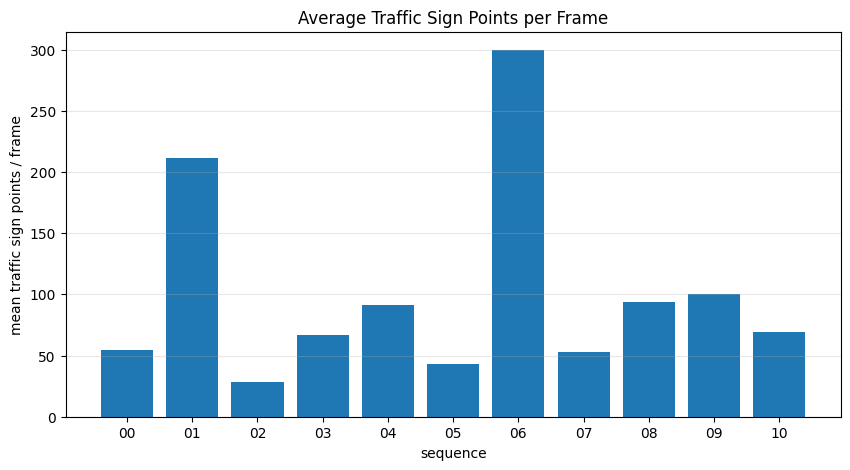

In [13]:
plt.figure(figsize=(10, 5))
plt.bar(seq_df["sequence"], seq_df["traffic_points_mean"])
plt.xlabel("sequence")
plt.ylabel("mean traffic sign points / frame")
plt.title("Average Traffic Sign Points per Frame")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

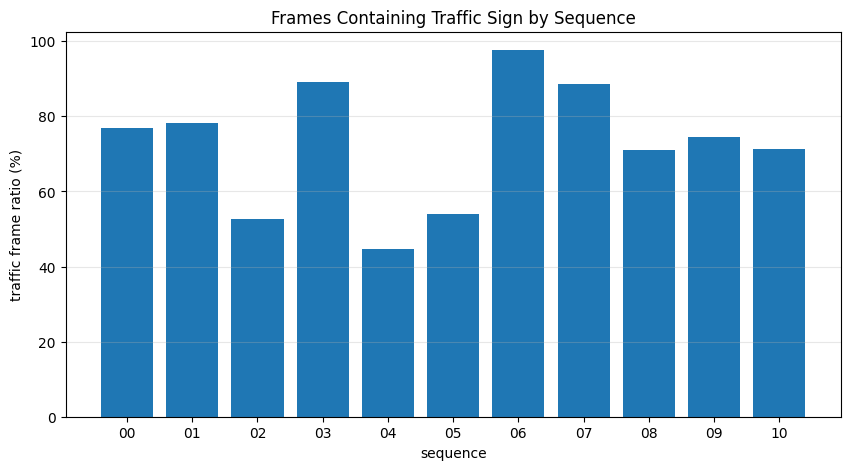

In [14]:
plt.figure(figsize=(10, 5))
plt.bar(seq_df["sequence"], seq_df["traffic_frame_ratio(%)"])
plt.xlabel("sequence")
plt.ylabel("traffic frame ratio (%)")
plt.title("Frames Containing Traffic Sign by Sequence")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

- 대부분의 Sequence에서 Traffic Sign이 포함된 Frame 비율은 50~90% 수준
- Frame당 평균 Point 수는 상대적으로 매우 적음

#### Traffic Sign 거리 및 위치 분석

In [15]:
distance_bins = np.arange(0, 121, 10)

distance_labels = [
    f"{distance_bins[i]}-{distance_bins[i+1]}m"
    for i in range(len(distance_bins) - 1)
]

distance_counts = np.zeros(len(distance_labels), dtype=int)

for label_file in sorted(LABEL_DIR.glob("*.label")):
    frame_id = label_file.stem

    points = np.fromfile(
        VELODYNE_DIR / f"{frame_id}.bin",
        dtype=np.float32
    ).reshape(-1, 4)

    labels = np.fromfile(label_file, dtype=np.uint32)
    sem = labels & 0xFFFF

    traffic_points = points[sem == TRAFFIC_SIGN_ID, :3]

    if len(traffic_points) == 0:
        continue

    # XY distance
    dist = np.linalg.norm(traffic_points[:, :2], axis=1)

    counts, _ = np.histogram(dist, bins=distance_bins)
    distance_counts += counts

distance_df = pd.DataFrame({
    "distance_range": distance_labels,
    "traffic_point_count": distance_counts,
})

distance_df["ratio(%)"] = (
    distance_df["traffic_point_count"]
    / distance_df["traffic_point_count"].sum()
    * 100
)

distance_df

,distance_range,traffic_point_count,ratio(%)
0,0-10m,114235,29.948197
1,10-20m,154382,40.473257
2,20-30m,65493,17.169845
3,30-40m,29304,7.682426
4,40-50m,17926,4.699535
5,50-60m,50,0.013108
6,60-70m,36,0.009438
7,70-80m,16,0.004195
8,80-90m,0,0.000000
9,90-100m,0,0.000000


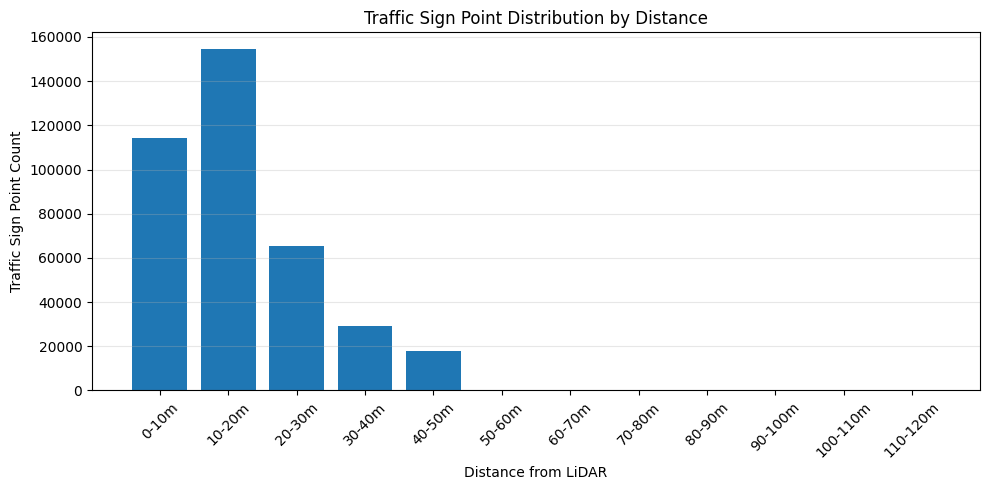

In [16]:
plt.figure(figsize=(10, 5))
plt.bar(distance_df["distance_range"], distance_df["traffic_point_count"])

plt.xlabel("Distance from LiDAR")
plt.ylabel("Traffic Sign Point Count")
plt.title("Traffic Sign Point Distribution by Distance")

plt.xticks(rotation=45)
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

- Traffic Sign Point의 약 70% 이상이 20m 이내에 집중
- 30m 이후부터는 Point 수가 급격하게 감소하며,50m 이상에서는 거의 관측되지 않음

#### Point Density 분석

In [17]:
# Traffic Sign 객체 단위의 거리별 Point Density 분석
# DBSCAN으로 객체 후보를 나눈 뒤, cluster 중심 거리와 point 수를 함께 확인한다.

from sklearn.cluster import DBSCAN

point_density_rows = []

for label_file in sorted(LABEL_DIR.glob("*.label")):
    frame_id = label_file.stem
    bin_file = VELODYNE_DIR / f"{frame_id}.bin"

    points = np.fromfile(bin_file, dtype=np.float32).reshape(-1, 4)
    labels = np.fromfile(label_file, dtype=np.uint32)
    sem = labels & 0xFFFF

    traffic_points = points[sem == TRAFFIC_SIGN_ID]

    if len(traffic_points) == 0:
        continue

    clustering = DBSCAN(eps=1.0, min_samples=3).fit(traffic_points[:, :3])
    cluster_labels = clustering.labels_

    for cid in sorted(set(cluster_labels)):
        if cid == -1:
            continue

        cluster_pts = traffic_points[cluster_labels == cid, :3]
        center = cluster_pts.mean(axis=0)
        distance = np.linalg.norm(center[:2])

        point_density_rows.append({
            "frame_id": frame_id,
            "cluster_id": cid,
            "distance_m": distance,
            "point_count": len(cluster_pts),
        })

point_density_df = pd.DataFrame(point_density_rows)

point_density_df["distance_bin"] = pd.cut(
    point_density_df["distance_m"],
    bins=distance_bins,
    labels=distance_labels,
    right=False
)

point_density_summary = (
    point_density_df
    .groupby("distance_bin", observed=False)
    .agg(
        cluster_count=("point_count", "count"),
        mean_point_count=("point_count", "mean"),
        median_point_count=("point_count", "median"),
        min_point_count=("point_count", "min"),
        max_point_count=("point_count", "max"),
    )
    .reset_index()
)

point_density_summary

,distance_bin,cluster_count,mean_point_count,median_point_count,min_point_count,max_point_count
0,0-10m,1139,100.141352,30.0,3.0,1186.0
1,10-20m,2671,57.449270,41.0,3.0,329.0
2,20-30m,2391,27.498536,20.0,3.0,110.0
3,30-40m,1892,15.266385,12.0,3.0,89.0
4,40-50m,1576,11.015228,9.0,3.0,59.0
5,50-60m,9,4.888889,5.0,4.0,6.0
6,60-70m,8,4.000000,4.0,3.0,5.0
7,70-80m,3,3.666667,4.0,3.0,4.0
8,80-90m,0,NaN,NaN,NaN,NaN
9,90-100m,0,NaN,NaN,NaN,NaN


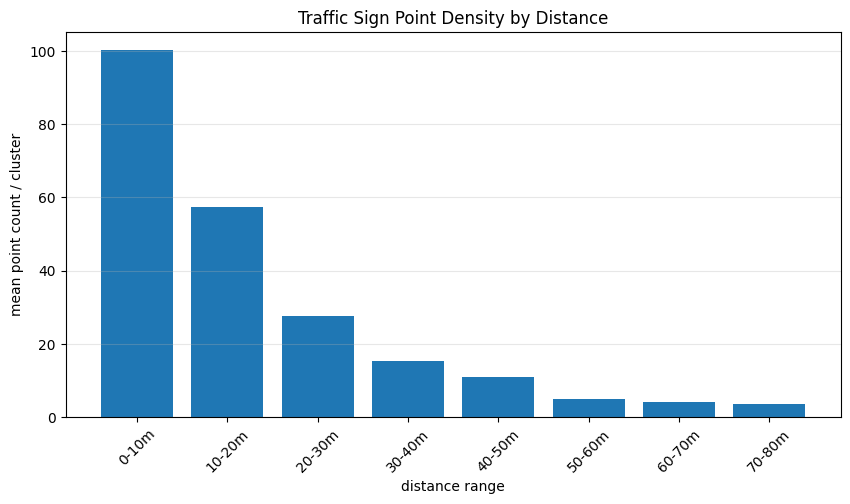

In [18]:
plt.figure(figsize=(10, 5))
plt.bar(
    point_density_summary["distance_bin"].astype(str),
    point_density_summary["mean_point_count"]
)
plt.xlabel("distance range")
plt.ylabel("mean point count / cluster")
plt.title("Traffic Sign Point Density by Distance")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.show()

- 거리 증가에 따라 Traffic sign의 Point 수 감소
- 평균 Point 수는 0~10m 구간에서 약 100개이며,40~50m에서는 약 11개 수준까지 감소  
    
→ 먼 거리에서는 Clustering이 불안정해질 수 있고, min points나 distance filtering 조건을 함께 고려해야 한다.


#### Traffic Sign 높이(Z) 분포 분석

Traffic Sign은 도로 위의 표지판이기 때문에 일반적으로 일정한 높이 범위에 분포한다.

따라서 z 분포를 확인하면, Pole이나 Noise처럼 표지판이 아닌 객체를 제거하기 위한 Height Filtering 기준을 잡는 데 활용할 수 있다.


In [19]:
traffic_z_values = []
traffic_center_z_values = []
traffic_height_rows = []

for label_file in sorted(LABEL_DIR.glob("*.label")):
    frame_id = label_file.stem
    bin_file = VELODYNE_DIR / f"{frame_id}.bin"

    points = np.fromfile(bin_file, dtype=np.float32).reshape(-1, 4)
    labels = np.fromfile(label_file, dtype=np.uint32)
    sem = labels & 0xFFFF

    traffic_points = points[sem == TRAFFIC_SIGN_ID]

    if len(traffic_points) == 0:
        continue

    traffic_z_values.extend(traffic_points[:, 2].tolist())

    clustering = DBSCAN(eps=1.0, min_samples=3).fit(traffic_points[:, :3])
    cluster_labels = clustering.labels_

    for cid in sorted(set(cluster_labels)):
        if cid == -1:
            continue

        cluster_pts = traffic_points[cluster_labels == cid, :3]
        z_min = cluster_pts[:, 2].min()
        z_max = cluster_pts[:, 2].max()
        z_center = cluster_pts[:, 2].mean()
        height = z_max - z_min

        traffic_center_z_values.append(z_center)
        traffic_height_rows.append({
            "frame_id": frame_id,
            "cluster_id": cid,
            "z_min": z_min,
            "z_max": z_max,
            "z_center": z_center,
            "height": height,
            "point_count": len(cluster_pts),
        })

height_df = pd.DataFrame(traffic_height_rows)

print("Traffic Sign point z statistics")
print(pd.Series(traffic_z_values).describe())

print("Traffic Sign cluster height statistics")
display(height_df.describe())

Traffic Sign point z statistics
count    381442.000000
mean          0.048960
std           0.703890
min          -3.236436
25%          -0.521247
50%           0.250294
75%           0.560253
max           2.132905
dtype: float64
Traffic Sign cluster height statistics


,cluster_id,z_min,z_max,z_center,height,point_count
count,9689.000000,9689.000000,9689.000000,9689.000000,9689.000000,9689.000000
mean,2.404273,0.087901,0.643418,0.391945,0.555517,39.177211
std,2.563187,0.724570,0.612121,0.644212,0.398723,72.024700
min,0.000000,-3.236436,-2.314438,-2.678493,0.000009,3.000000
25%,0.000000,-0.271365,0.378358,0.122995,0.267898,9.000000
50%,2.000000,0.191884,0.710894,0.492595,0.498058,17.000000
75%,4.000000,0.547365,1.017716,0.770836,0.745897,42.000000
max,13.000000,1.916369,1.989986,1.920883,2.515082,1186.000000


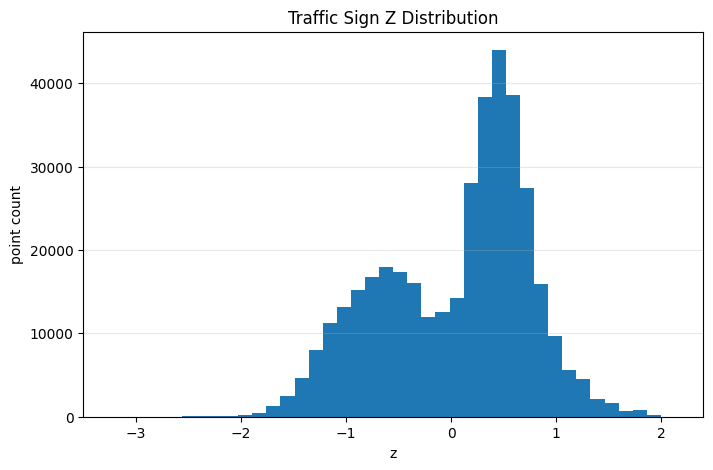

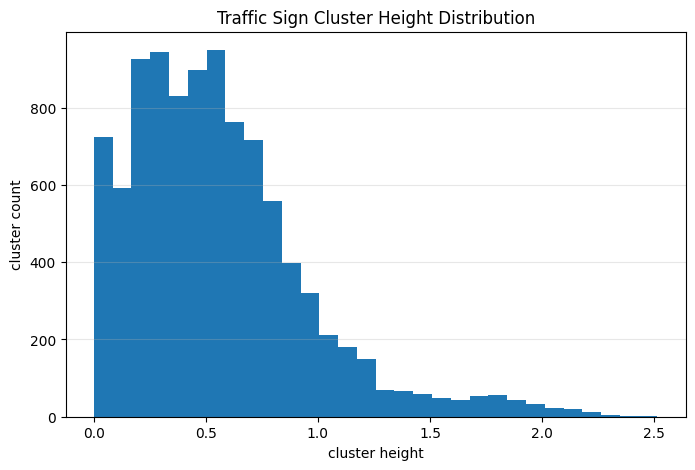

In [20]:
plt.figure(figsize=(8, 5))
plt.hist(traffic_z_values, bins=40)
plt.xlabel("z")
plt.ylabel("point count")
plt.title("Traffic Sign Z Distribution")
plt.grid(axis="y", alpha=0.3)
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(height_df["height"], bins=30)
plt.xlabel("cluster height")
plt.ylabel("cluster count")
plt.title("Traffic Sign Cluster Height Distribution")
plt.grid(axis="y", alpha=0.3)
plt.show()

→ Traffic Sign의 z 값과 cluster height 분포를 확인하면, 너무 낮거나 너무 높은 후보를 제거하는 기준을 만들 수 있다.  
→ Bounding Box 생성 과정에서 Height Filtering 조건으로 활용할 수 있다.


#### DBSCAN을 활용한 클러스터링 분석

DBSCAN은 밀도 기반 클러스터링 방법으로, 가까운 point들을 하나의 객체 후보로 묶고 주변과 떨어진 point는 noise로 처리할 수 있다.

Traffic Sign처럼 point 수가 적고 작은 객체에서는 `eps`, `min_samples` 값에 따라 결과가 크게 달라질 수 있으므로, cluster 개수와 point 수 분포를 함께 확인했다.


In [21]:
from sklearn.cluster import DBSCAN

cluster_rows = []

for label_file in sorted(LABEL_DIR.glob("*.label")):
    frame_id = label_file.stem

    bin_file = VELODYNE_DIR / f"{frame_id}.bin"

    points = np.fromfile(bin_file, dtype=np.float32).reshape(-1, 4)

    labels = np.fromfile(label_file, dtype=np.uint32)
    sem = labels & 0xFFFF

    traffic_points = points[sem == TRAFFIC_SIGN_ID]

    if len(traffic_points) == 0:
        continue

    clustering = DBSCAN(eps=1.0, min_samples=3).fit(traffic_points[:, :3])
    cluster_labels = clustering.labels_

    for cid in sorted(set(cluster_labels)):
        if cid == -1:
            continue

        cluster_pts = traffic_points[cluster_labels == cid, :3]
        center = cluster_pts.mean(axis=0)
        distance = np.linalg.norm(center[:2])

        cluster_rows.append({
            "frame_id": frame_id,
            "cluster_id": cid,
            "point_count": len(cluster_pts),
            "center_x": center[0],
            "center_y": center[1],
            "center_z": center[2],
            "distance_m": distance,
        })

cluster_df = pd.DataFrame(cluster_rows)

print("traffic sign clusters:", len(cluster_df))
display(cluster_df.head())

traffic sign clusters: 9689


,frame_id,cluster_id,point_count,center_x,center_y,center_z,distance_m
0,000000,0,34,27.409544,8.618876,1.000182,28.732700
1,000000,1,17,29.668295,16.368210,1.098576,33.884007
2,000000,2,20,17.058939,15.164029,0.694731,22.824444
3,000000,3,26,-7.977165,-4.317446,0.526016,9.070584
4,000000,4,654,0.891752,-4.622035,-0.077846,4.707274


count    9689.000000
mean       39.177211
std        72.024700
min         3.000000
25%         9.000000
50%        17.000000
75%        42.000000
max      1186.000000
Name: point_count, dtype: float64


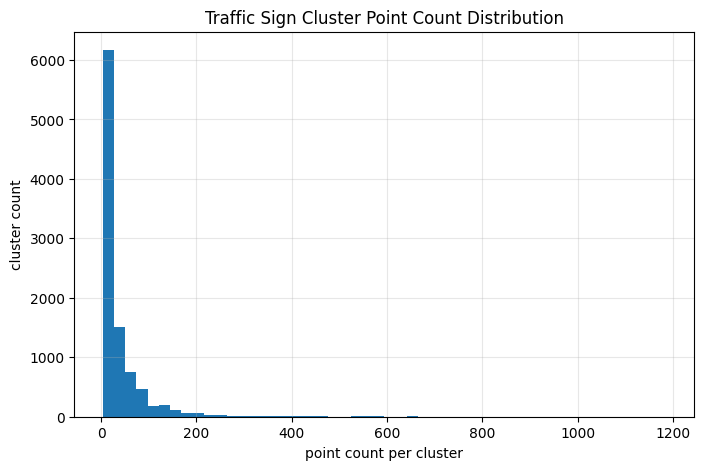

In [22]:
print(cluster_df["point_count"].describe())

plt.figure(figsize=(8, 5))
plt.hist(cluster_df["point_count"], bins=50)
plt.xlabel("point count per cluster")
plt.ylabel("cluster count")
plt.title("Traffic Sign Cluster Point Count Distribution")
plt.grid(True, alpha=0.3)
plt.show()

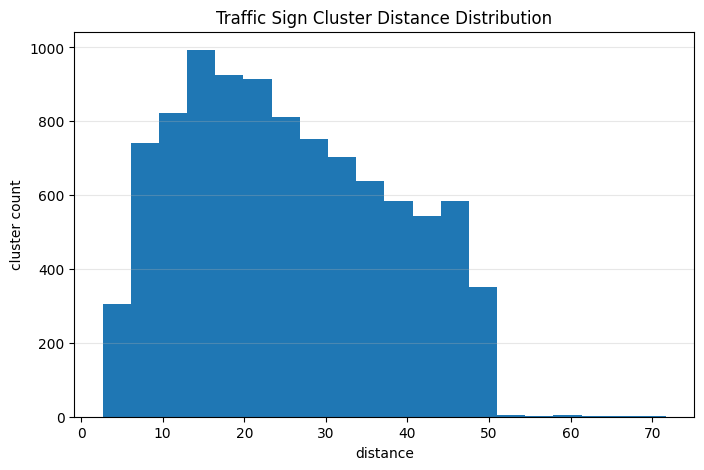

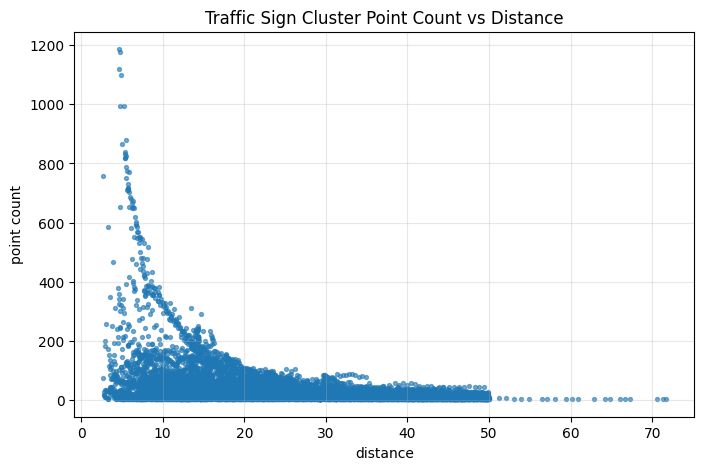

In [23]:
plt.figure(figsize=(8, 5))
plt.hist(cluster_df["distance_m"], bins=20)
plt.xlabel("distance")
plt.ylabel("cluster count")
plt.title("Traffic Sign Cluster Distance Distribution")
plt.grid(axis="y", alpha=0.3)
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(cluster_df["distance_m"], cluster_df["point_count"], s=8, alpha=0.6)
plt.xlabel("distance")
plt.ylabel("point count")
plt.title("Traffic Sign Cluster Point Count vs Distance")
plt.grid(alpha=0.3)
plt.show()

#### Voxel Connected Components을 활용한 클러스터링 분석

Voxel Connected Components는 point를 일정한 크기의 voxel grid로 나눈 뒤, 서로 인접한 voxel들을 하나의 cluster로 묶는 방식이다.

```text
Point Cloud
     ↓
Voxelization
     ↓
Connected Component 탐색
     ↓
Cluster 생성
```

DBSCAN이 point 간 거리와 밀도를 기준으로 동작한다면, Voxel 방식은 공간을 grid로 나누어 연결성을 확인한다.  
작은 객체를 세분화해서 볼 수 있지만, voxel size에 따라 하나의 객체가 여러 cluster로 나뉠 수 있다.


In [24]:
from collections import deque

VOXEL_SIZE = 0.5

voxel_cluster_rows = []

# 26-neighbor
neighbors = []
for dx in [-1, 0, 1]:
    for dy in [-1, 0, 1]:
        for dz in [-1, 0, 1]:
            if dx == 0 and dy == 0 and dz == 0:
                continue
            neighbors.append((dx, dy, dz))

for label_file in sorted(LABEL_DIR.glob("*.label")):
    frame_id = label_file.stem

    bin_file = VELODYNE_DIR / f"{frame_id}.bin"

    points = np.fromfile(bin_file, dtype=np.float32).reshape(-1, 4)

    labels = np.fromfile(label_file, dtype=np.uint32)
    sem = labels & 0xFFFF

    traffic_points = points[sem == TRAFFIC_SIGN_ID]

    if len(traffic_points) == 0:
        continue

    xyz = traffic_points[:, :3]

    voxel_idx = np.floor(xyz / VOXEL_SIZE).astype(np.int32)

    voxel_to_points = {}
    for i, v in enumerate(voxel_idx):
        key = tuple(v)
        if key not in voxel_to_points:
            voxel_to_points[key] = []
        voxel_to_points[key].append(i)

    voxel_set = set(voxel_to_points.keys())
    visited = set()
    cluster_id = 0

    for voxel in voxel_set:
        if voxel in visited:
            continue

        q = deque([voxel])
        visited.add(voxel)

        component_voxels = []

        while q:
            cur = q.popleft()
            component_voxels.append(cur)

            for nb in neighbors:
                nxt = (cur[0] + nb[0], cur[1] + nb[1], cur[2] + nb[2])

                if nxt in voxel_set and nxt not in visited:
                    visited.add(nxt)
                    q.append(nxt)

        point_indices = []
        for v in component_voxels:
            point_indices.extend(voxel_to_points[v])

        cluster_pts = xyz[point_indices]

        center = cluster_pts.mean(axis=0)
        distance = np.linalg.norm(center[:2])

        voxel_cluster_rows.append({
            "frame_id": frame_id,
            "cluster_id": cluster_id,
            "point_count": len(cluster_pts),
            "voxel_count": len(component_voxels),
            "center_x": center[0],
            "center_y": center[1],
            "center_z": center[2],
            "distance_m": distance,
        })

        cluster_id += 1

voxel_cluster_df = pd.DataFrame(voxel_cluster_rows)

print("traffic sign voxel clusters:", len(voxel_cluster_df))
display(voxel_cluster_df.head())

print(voxel_cluster_df["point_count"].describe())

traffic sign voxel clusters: 11222


,frame_id,cluster_id,point_count,voxel_count,center_x,center_y,center_z,distance_m
0,000000,0,26,4,-7.977165,-4.317445,0.526016,9.070584
1,000000,1,8,7,27.002098,22.973063,-1.002838,35.452431
2,000000,2,20,4,17.058939,15.164027,0.694731,22.824440
3,000000,3,34,8,27.409546,8.618877,1.000182,28.732704
4,000000,4,17,5,29.668297,16.368210,1.098576,33.884010


count    11222.000000
mean        33.990554
std         67.767721
min          1.000000
25%          6.000000
50%         14.000000
75%         35.000000
max       1186.000000
Name: point_count, dtype: float64


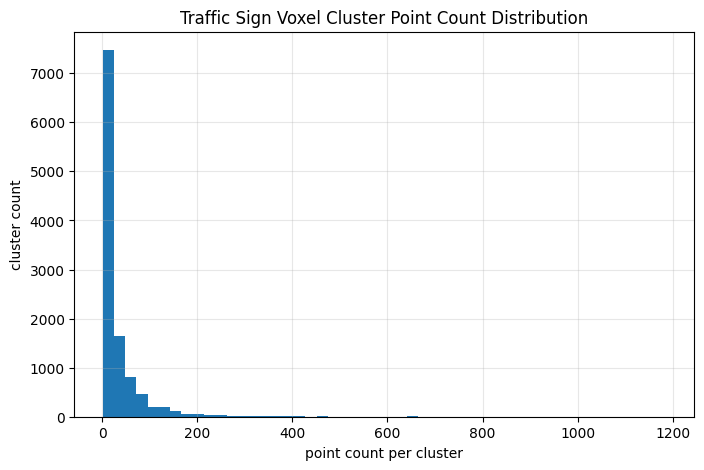

In [25]:

plt.figure(figsize=(8, 5))
plt.hist(voxel_cluster_df["point_count"], bins=50)
plt.xlabel("point count per cluster")
plt.ylabel("cluster count")
plt.title("Traffic Sign Voxel Cluster Point Count Distribution")
plt.grid(True, alpha=0.3)
plt.show()

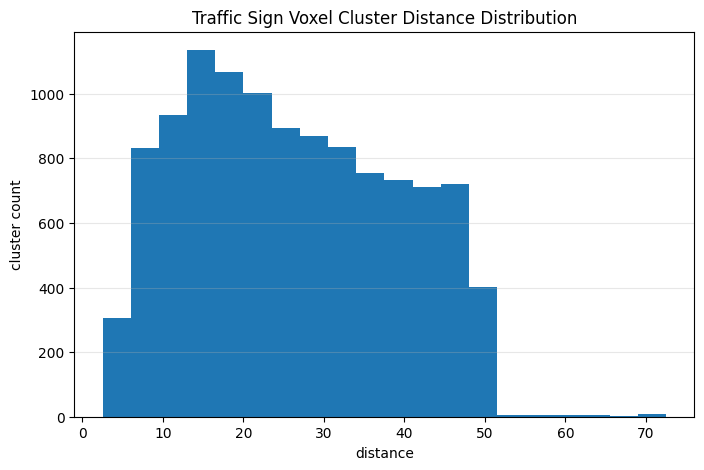

In [26]:

plt.figure(figsize=(8, 5))
plt.hist(voxel_cluster_df["distance_m"], bins=20)
plt.xlabel("distance")
plt.ylabel("cluster count")
plt.title("Traffic Sign Voxel Cluster Distance Distribution")
plt.grid(axis="y", alpha=0.3)
plt.show()

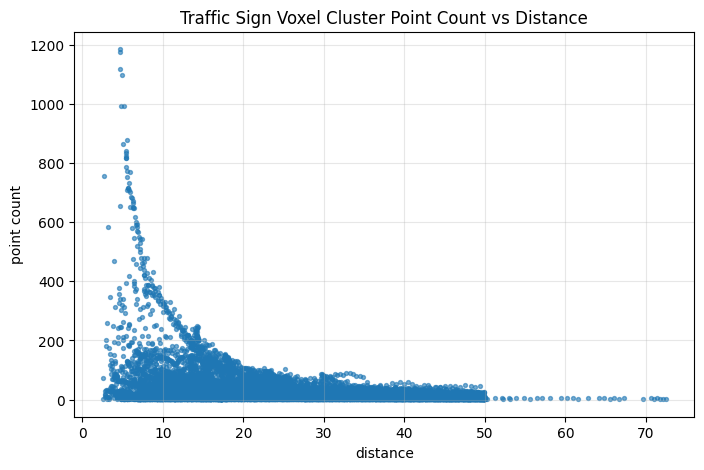

In [27]:

plt.figure(figsize=(8, 5))
plt.scatter(voxel_cluster_df["distance_m"], voxel_cluster_df["point_count"], s=8, alpha=0.6)
plt.xlabel("distance")
plt.ylabel("point count")
plt.title("Traffic Sign Voxel Cluster Point Count vs Distance")
plt.grid(alpha=0.3)
plt.show()

#### DBSCAN vs VOXEL Connected Components 비교 분석

In [28]:
# =========================
# DBSCAN vs Voxel frame별 차이 비교
# =========================

dbscan_frame_count = (
    cluster_df
    .groupby("frame_id")
    .size()
    .reset_index(name="dbscan_clusters")
)

voxel_frame_count = (
    voxel_cluster_df
    .groupby("frame_id")
    .size()
    .reset_index(name="voxel_clusters")
)

frame_compare_df = pd.merge(
    dbscan_frame_count,
    voxel_frame_count,
    on="frame_id",
    how="outer"
).fillna(0)

frame_compare_df["dbscan_clusters"] = frame_compare_df["dbscan_clusters"].astype(int)
frame_compare_df["voxel_clusters"] = frame_compare_df["voxel_clusters"].astype(int)

frame_compare_df["diff"] = (
    frame_compare_df["dbscan_clusters"] - frame_compare_df["voxel_clusters"]
)

# cluster 수가 다른 frame만 추출
diff_df = frame_compare_df[frame_compare_df["diff"] != 0].copy()

print("different frames:", len(diff_df))
display(diff_df.head())

different frames: 1110


,frame_id,dbscan_clusters,voxel_clusters,diff
2,000002,8,9,-1
3,000003,7,8,-1
4,000004,7,8,-1
7,000007,7,8,-1
8,000008,7,8,-1


In [43]:
print("=" * 50)

dbscan_more = (frame_compare_df["dbscan_clusters"] > frame_compare_df["voxel_clusters"]).sum()
voxel_more = (frame_compare_df["dbscan_clusters"] < frame_compare_df["voxel_clusters"]).sum()
same = (frame_compare_df["dbscan_clusters"] == frame_compare_df["voxel_clusters"]).sum()

print(f"DBSCAN > Voxel : {dbscan_more}")
print(f"Voxel > DBSCAN : {voxel_more}")
print(f"Same           : {same}")

print("=" * 50)

print("Average clusters per frame")
print(f"DBSCAN : {frame_compare_df['dbscan_clusters'].mean():.2f}")
print(f"Voxel  : {frame_compare_df['voxel_clusters'].mean():.2f}")

DBSCAN > Voxel : 7
Voxel > DBSCAN : 1103
Same           : 1778
Average clusters per frame
DBSCAN : 3.35
Voxel  : 3.89


In [30]:
# =========================
# Frame별 Cluster 수 비교
# =========================

dbscan_frame_count = (
    cluster_df
    .groupby("frame_id")
    .size()
    .reset_index(name="dbscan_clusters")
)

voxel_frame_count = (
    voxel_cluster_df
    .groupby("frame_id")
    .size()
    .reset_index(name="voxel_clusters")
)

frame_compare_df = pd.merge(
    dbscan_frame_count,
    voxel_frame_count,
    on="frame_id",
    how="outer"
).fillna(0)

frame_compare_df["dbscan_clusters"] = frame_compare_df["dbscan_clusters"].astype(int)
frame_compare_df["voxel_clusters"] = frame_compare_df["voxel_clusters"].astype(int)
frame_compare_df["diff"] = frame_compare_df["dbscan_clusters"] - frame_compare_df["voxel_clusters"]

display(frame_compare_df.head())

print("=" * 50)
print("Frame-level comparison")
print(f"DBSCAN > Voxel : {(frame_compare_df['dbscan_clusters'] > frame_compare_df['voxel_clusters']).sum()}")
print(f"Voxel > DBSCAN : {(frame_compare_df['dbscan_clusters'] < frame_compare_df['voxel_clusters']).sum()}")
print(f"Same           : {(frame_compare_df['dbscan_clusters'] == frame_compare_df['voxel_clusters']).sum()}")
print("=" * 50)

print("Average clusters per frame")
print(f"DBSCAN : {frame_compare_df['dbscan_clusters'].mean():.2f}")
print(f"Voxel  : {frame_compare_df['voxel_clusters'].mean():.2f}")

,frame_id,dbscan_clusters,voxel_clusters,diff
0,000000,8,8,0
1,000001,8,8,0
2,000002,8,9,-1
3,000003,7,8,-1
4,000004,7,8,-1


Frame-level comparison
DBSCAN > Voxel : 7
Voxel > DBSCAN : 1103
Same           : 1778
Average clusters per frame
DBSCAN : 3.35
Voxel  : 3.89


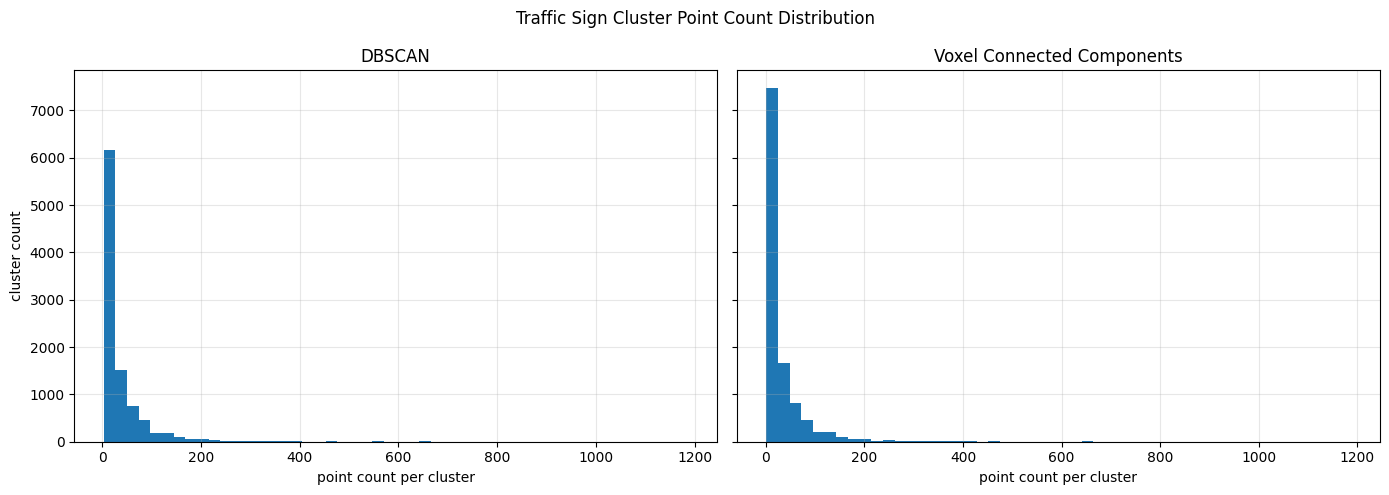

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

axes[0].hist(cluster_df["point_count"], bins=50)
axes[0].set_title("DBSCAN")
axes[0].set_xlabel("point count per cluster")
axes[0].set_ylabel("cluster count")
axes[0].grid(True, alpha=0.3)

axes[1].hist(voxel_cluster_df["point_count"], bins=50)
axes[1].set_title("Voxel Connected Components")
axes[1].set_xlabel("point count per cluster")
axes[1].grid(True, alpha=0.3)

plt.suptitle("Traffic Sign Cluster Point Count Distribution")
plt.tight_layout()
plt.show()

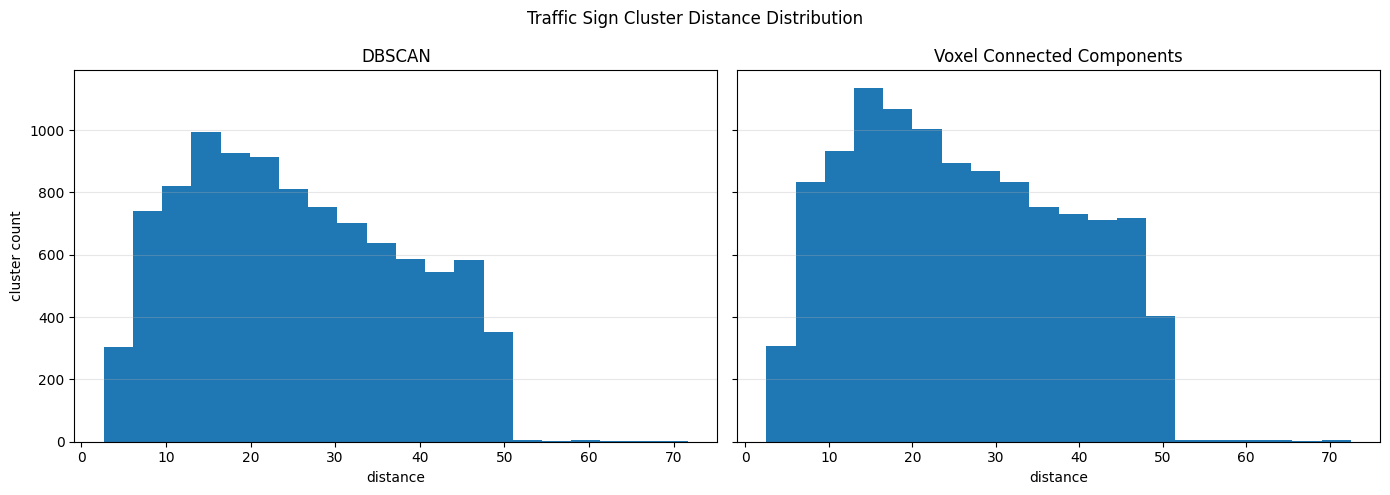

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

axes[0].hist(cluster_df["distance_m"], bins=20)
axes[0].set_title("DBSCAN")
axes[0].set_xlabel("distance")
axes[0].set_ylabel("cluster count")
axes[0].grid(axis="y", alpha=0.3)

axes[1].hist(voxel_cluster_df["distance_m"], bins=20)
axes[1].set_title("Voxel Connected Components")
axes[1].set_xlabel("distance")
axes[1].grid(axis="y", alpha=0.3)

plt.suptitle("Traffic Sign Cluster Distance Distribution")
plt.tight_layout()
plt.show()

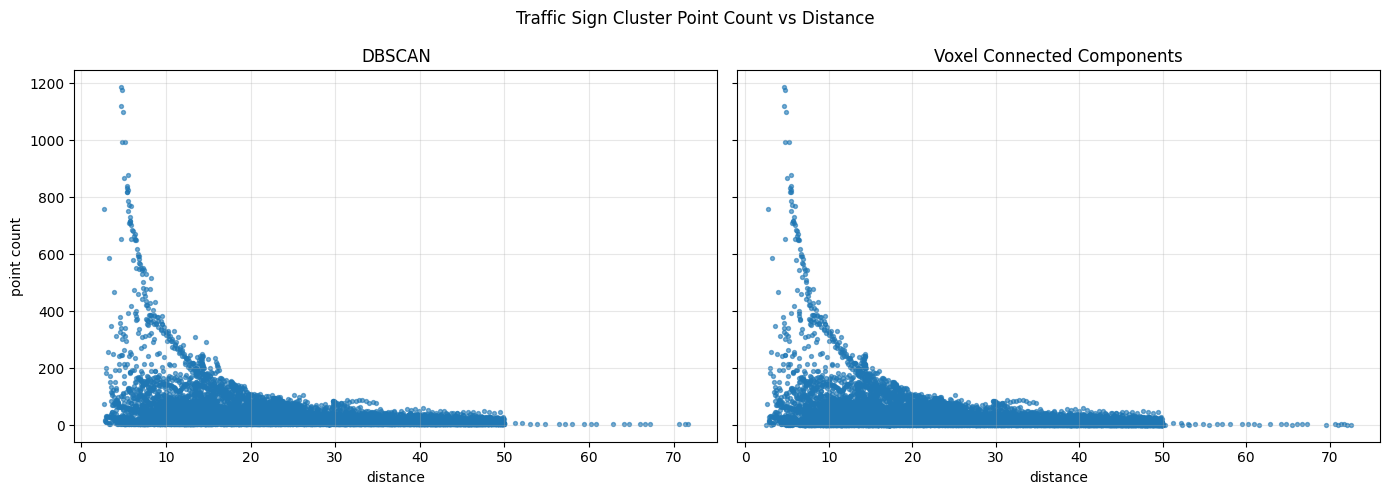

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

axes[0].scatter(
    cluster_df["distance_m"],
    cluster_df["point_count"],
    s=8,
    alpha=0.6
)
axes[0].set_title("DBSCAN")
axes[0].set_xlabel("distance")
axes[0].set_ylabel("point count")
axes[0].grid(alpha=0.3)

axes[1].scatter(
    voxel_cluster_df["distance_m"],
    voxel_cluster_df["point_count"],
    s=8,
    alpha=0.6
)
axes[1].set_title("Voxel Connected Components")
axes[1].set_xlabel("distance")
axes[1].grid(alpha=0.3)

plt.suptitle("Traffic Sign Cluster Point Count vs Distance")
plt.tight_layout()
plt.show()

- **Voxel Connected Components**는 연산 속도가 빠르고 희소한 Point도 Cluster로 유지될 가능성이 높다는 장점이 있다. 그러나 Voxel Size에 따라 하나의 객체가 여러 Cluster로 분리되거나, 인접한 객체가 하나의 Cluster로 병합될 수 있다.

- **DBSCAN**은 `eps`와 `min_samples` 등의 threshold를 적절히 조정해야 하지만, Point 간 거리와 밀도를 기반으로 Cluster를 생성하며 noise Point를 자동으로 제거할 수 있다는 장점이 있다.

→ **실시간 처리 속도보다 객체 단위의 정확한 3D Bounding Box 생성**이 더 중요한 요소이기에 Clustering의 안정성과 객체 분리 성능을 고려하여 **DBSCAN을 최종 Clustering 방법으로 선택하였다.**

#### BEV 시각화

전체 point cloud와 traffic sign 포인트를 BEV 기준으로 시각화했다.  

In [34]:
# Traffic Sign이 포함된 frame 중 일부를 자동으로 선택하여 BEV 예시를 여러 개 확인한다.

traffic_frame_counts = []

for label_file in sorted(LABEL_DIR.glob("*.label")):
    frame_id = label_file.stem
    labels = np.fromfile(label_file, dtype=np.uint32)
    sem = labels & 0xFFFF
    cnt = int(np.sum(sem == TRAFFIC_SIGN_ID))

    if cnt > 0:
        traffic_frame_counts.append({
            "frame_id": frame_id,
            "traffic_points": cnt,
        })

traffic_frame_df = pd.DataFrame(traffic_frame_counts).sort_values("traffic_points", ascending=False)

# point 수가 많은 frame 위주로 4개 선택
example_frames = traffic_frame_df.head(4)["frame_id"].tolist()
example_frames

['000076', '000077', '000075', '000078']

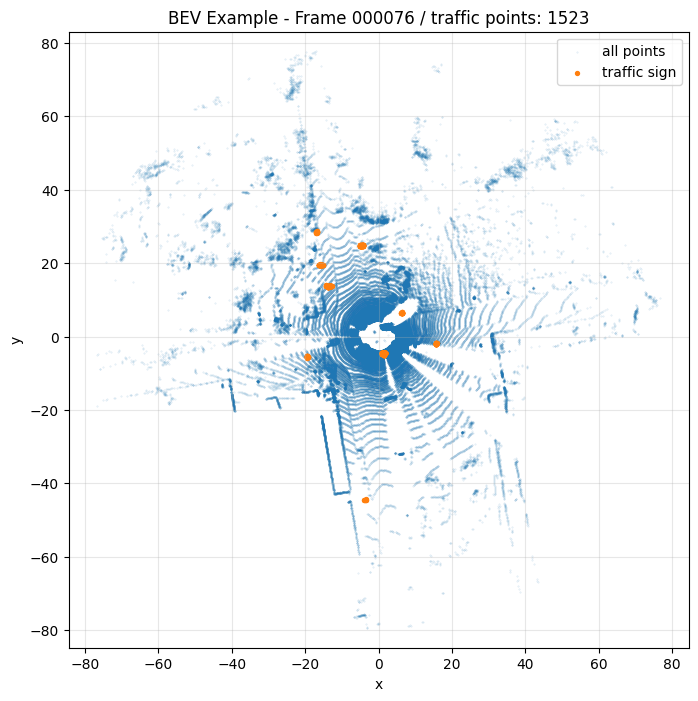

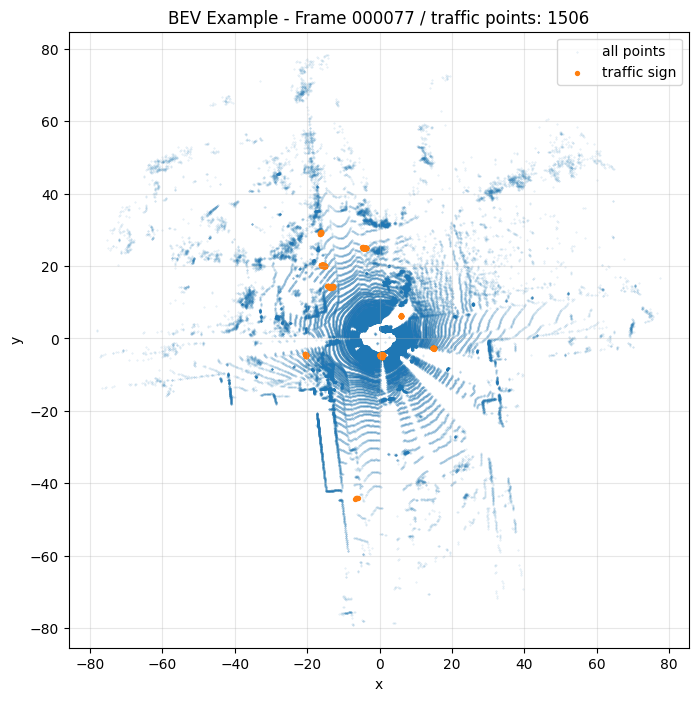

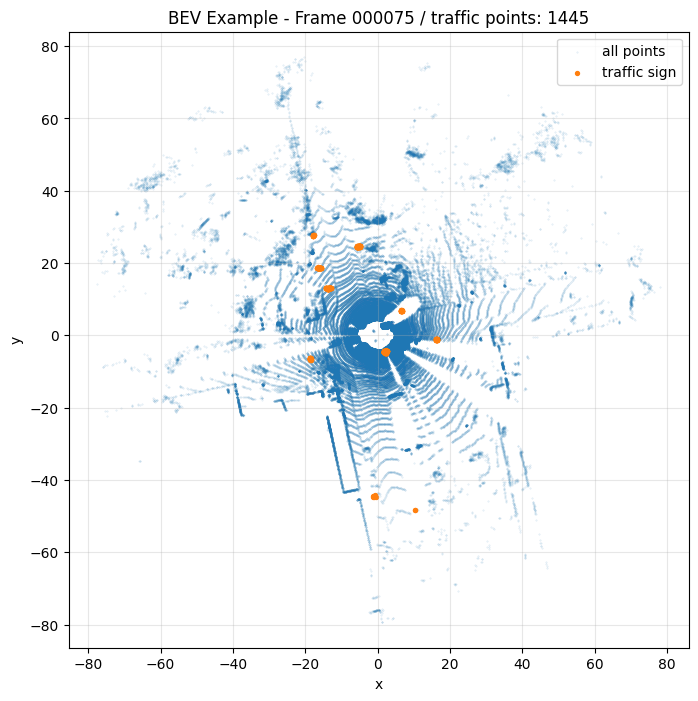

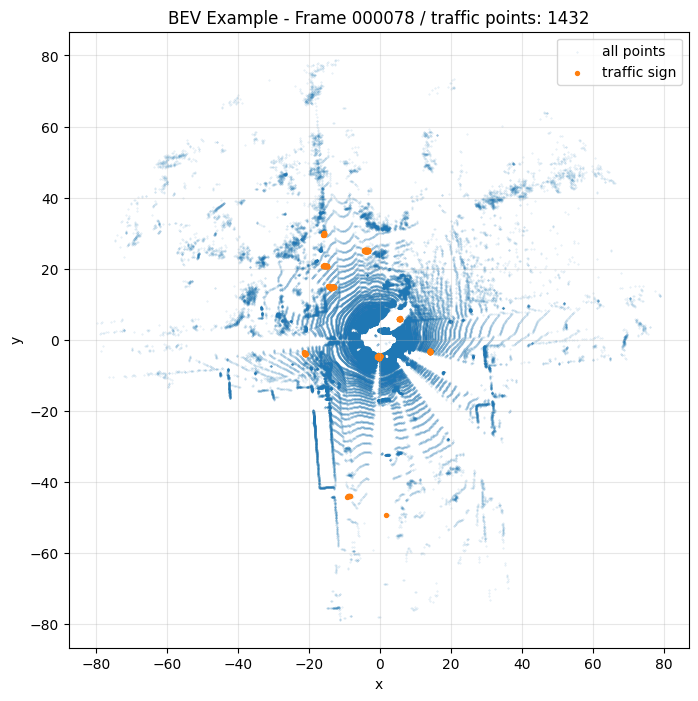

In [35]:
for frame_id in example_frames:
    bin_file = VELODYNE_DIR / f"{frame_id}.bin"
    label_file = LABEL_DIR / f"{frame_id}.label"

    points = np.fromfile(bin_file, dtype=np.float32).reshape(-1, 4)
    labels = np.fromfile(label_file, dtype=np.uint32)
    sem = labels & 0xFFFF
    traffic_points = points[sem == TRAFFIC_SIGN_ID]

    plt.figure(figsize=(8, 8))
    plt.scatter(points[:, 0], points[:, 1], s=0.1, alpha=0.2, label="all points")
    plt.scatter(traffic_points[:, 0], traffic_points[:, 1], s=8, label="traffic sign")

    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(f"BEV Example - Frame {frame_id} / traffic points: {len(traffic_points)}")
    plt.axis("equal")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()

In [36]:
# =====================
# Select Frame
# =====================

VIS_SEQ = "08"
VIS_FRAME = "000000"

bin_file = DATA_ROOT / "sequences" / VIS_SEQ / "velodyne" / f"{VIS_FRAME}.bin"
label_file = DATA_ROOT / "sequences" / VIS_SEQ / "labels" / f"{VIS_FRAME}.label"

points = np.fromfile(bin_file, dtype=np.float32).reshape(-1, 4)

labels = np.fromfile(label_file, dtype=np.uint32)
sem_labels = labels & 0xFFFF

traffic_points = points[sem_labels == TRAFFIC_SIGN_ID]

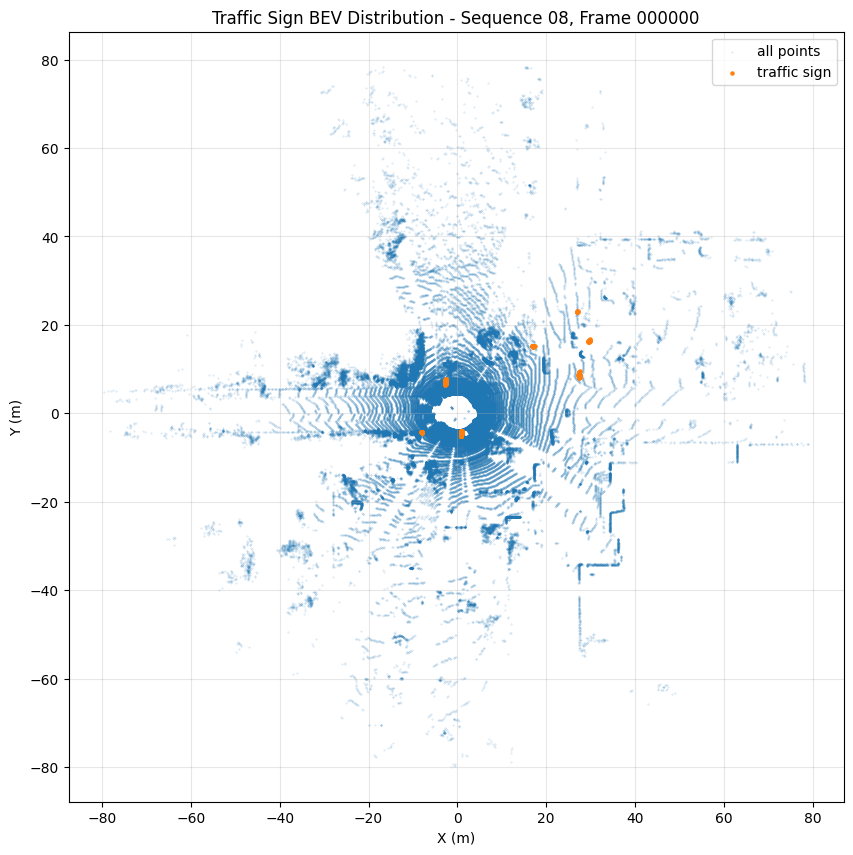

In [37]:
plt.figure(figsize=(10, 10))

plt.scatter(
    points[:, 0],
    points[:, 1],
    s=0.1,
    alpha=0.25,
    label="all points"
)

if len(traffic_points) > 0:
    plt.scatter(
        traffic_points[:, 0],
        traffic_points[:, 1],
        s=5,
        label="traffic sign"
    )

plt.xlabel("X (m)")
plt.ylabel("Y (m)")
plt.axis("equal")
plt.title(f"Traffic Sign BEV Distribution - Sequence {VIS_SEQ}, Frame {VIS_FRAME}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [38]:
bin_file = DATA_ROOT / "sequences" / VIS_SEQ / "velodyne" / f"{VIS_FRAME}.bin"
label_file = DATA_ROOT / "sequences" / VIS_SEQ / "labels" / f"{VIS_FRAME}.label"

points = np.fromfile(
    bin_file,
    dtype=np.float32
).reshape(-1, 4)

labels = np.fromfile(
    label_file,
    dtype=np.uint32
)

sem_labels = labels & 0xFFFF

traffic_points = points[sem_labels == TRAFFIC_SIGN_ID]

#### DBSCAN

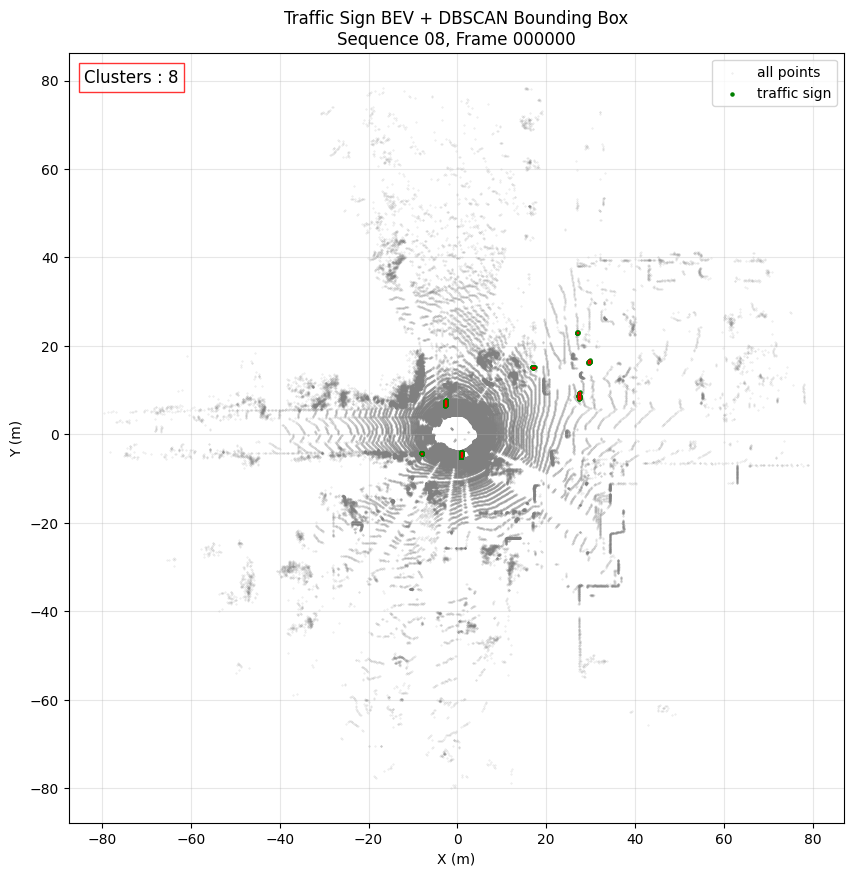

In [39]:
from sklearn.cluster import DBSCAN
from matplotlib.patches import Rectangle

plt.figure(figsize=(10, 10))

# All points
plt.scatter(
    points[:, 0],
    points[:, 1],
    s=0.1,
    alpha=0.25,
    c="gray",
    label="all points"
)

# Traffic Sign points
if len(traffic_points) > 0:
    plt.scatter(
        traffic_points[:, 0],
        traffic_points[:, 1],
        s=5,
        c="green",
        label="traffic sign"
    )

    # DBSCAN
    clustering = DBSCAN(eps=1.0, min_samples=3).fit(traffic_points[:, :3])
    cluster_labels = clustering.labels_
    num_clusters = np.sum(np.unique(cluster_labels) != -1)

    for cid in np.unique(cluster_labels):

        if cid == -1:
            continue

        cluster = traffic_points[cluster_labels == cid]

        # Bounding Box (XY)
        x_min, y_min = cluster[:, :2].min(axis=0)
        x_max, y_max = cluster[:, :2].max(axis=0)

        rect = Rectangle(
            (x_min, y_min),
            x_max - x_min,
            y_max - y_min,
            linewidth=1,
            edgecolor="red",
            facecolor="none"
        )

        plt.gca().add_patch(rect)


plt.xlabel("X (m)")
plt.ylabel("Y (m)")
plt.axis("equal")
plt.title(f"Traffic Sign BEV + DBSCAN Bounding Box\nSequence {VIS_SEQ}, Frame {VIS_FRAME}")
plt.text(
    0.02, 0.98,
    f"Clusters : {num_clusters}",
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment="top",
    bbox=dict(facecolor="white", alpha=0.8, edgecolor="red")
)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#### Voxel Connected Components

In [40]:
from collections import deque
from matplotlib.patches import Rectangle

def voxel_connected_components(points_xyz, voxel_size=0.5):
    voxel_coords = np.floor(points_xyz / voxel_size).astype(np.int32)

    voxel_to_indices = {}
    for i, voxel in enumerate(map(tuple, voxel_coords)):
        voxel_to_indices.setdefault(voxel, []).append(i)

    visited = set()
    clusters = []

    neighbors = [
        (dx, dy, dz)
        for dx in [-1, 0, 1]
        for dy in [-1, 0, 1]
        for dz in [-1, 0, 1]
        if not (dx == 0 and dy == 0 and dz == 0)
    ]

    for voxel in voxel_to_indices:
        if voxel in visited:
            continue

        queue = deque([voxel])
        visited.add(voxel)
        cluster_indices = []

        while queue:
            cur = queue.popleft()
            cluster_indices.extend(voxel_to_indices[cur])

            for dx, dy, dz in neighbors:
                nxt = (cur[0] + dx, cur[1] + dy, cur[2] + dz)

                if nxt in voxel_to_indices and nxt not in visited:
                    visited.add(nxt)
                    queue.append(nxt)

        clusters.append(cluster_indices)

    return clusters

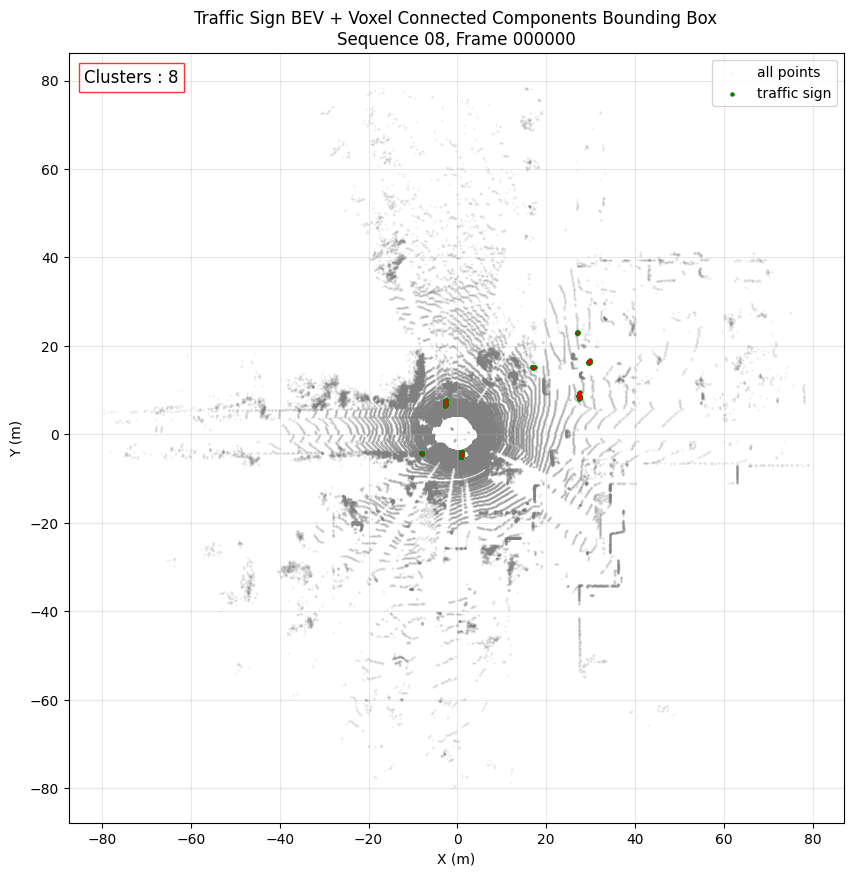

In [41]:
plt.figure(figsize=(10, 10))

plt.scatter(
    points[:, 0],
    points[:, 1],
    s=0.1,
    alpha=0.25,
    c="gray",
    label="all points"
)

num_clusters = 0

if len(traffic_points) > 0:
    plt.scatter(
        traffic_points[:, 0],
        traffic_points[:, 1],
        s=5,
        c="green",
        label="traffic sign"
    )

    clusters = voxel_connected_components(
        traffic_points[:, :3],
        voxel_size=0.5
    )

    for cluster_indices in clusters:
        cluster = traffic_points[cluster_indices]

        if len(cluster) < 3:
            continue

        num_clusters += 1

        x_min, y_min = cluster[:, :2].min(axis=0)
        x_max, y_max = cluster[:, :2].max(axis=0)

        rect = Rectangle(
            (x_min, y_min),
            x_max - x_min,
            y_max - y_min,
            linewidth=1,
            edgecolor="red",
            facecolor="none"
        )

        plt.gca().add_patch(rect)

plt.xlabel("X (m)")
plt.ylabel("Y (m)")
plt.axis("equal")
plt.title(f"Traffic Sign BEV + Voxel Connected Components Bounding Box\nSequence {VIS_SEQ}, Frame {VIS_FRAME}")
plt.text(
    0.02, 0.98,
    f"Clusters : {num_clusters}",
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment="top",
    bbox=dict(facecolor="white", alpha=0.8, edgecolor="red")
)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#### Bounding Box Filtering 방향

다음과 같은 filtering 조건을 적용할 수 있다.

- cluster point 수가 너무 적은 경우 제거
- LiDAR 기준 너무 먼 거리에 있는 경우 제거


In [42]:
bbox_rows = []

for _, row in cluster_df.iterrows():
    frame_id = row["frame_id"]
    cid = row["cluster_id"]

    bin_file = VELODYNE_DIR / f"{frame_id}.bin"
    label_file = LABEL_DIR / f"{frame_id}.label"

    points = np.fromfile(bin_file, dtype=np.float32).reshape(-1, 4)
    labels = np.fromfile(label_file, dtype=np.uint32)
    sem = labels & 0xFFFF
    traffic_points = points[sem == TRAFFIC_SIGN_ID]

    clustering = DBSCAN(eps=1.0, min_samples=3).fit(traffic_points[:, :3])
    cluster_labels = clustering.labels_
    cluster_pts = traffic_points[cluster_labels == cid, :3]

    xyz_min = cluster_pts.min(axis=0)
    xyz_max = cluster_pts.max(axis=0)
    extent = xyz_max - xyz_min
    center = (xyz_min + xyz_max) / 2
    distance = np.linalg.norm(center[:2])

    bbox_rows.append({
        "frame_id": frame_id,
        "cluster_id": cid,
        "point_count": len(cluster_pts),
        "center_x": center[0],
        "center_y": center[1],
        "center_z": center[2],
        "distance_m": distance,
        "width_x": extent[0],
        "width_y": extent[1],
        "height_z": extent[2],
    })

bbox_df = pd.DataFrame(bbox_rows)

# 분석용 예시 threshold
filtered_bbox_df = bbox_df[
    (bbox_df["point_count"] >= 3) &
    (bbox_df["distance_m"] <= 75)
].copy()

print("before filtering:", len(bbox_df))
print("after filtering :", len(filtered_bbox_df))

before filtering: 9689
after filtering : 9689


→ threshold 조정을 통해 GT를 최대한 유지하는 filtering threshold를 설정하였고, Prediction 결과의 후처리에도 동일하게 적용할 예정이다.


## 분석 결과 정리

- Traffic Sign은 전체 Point의 약 0.08%를 차지하는 희소 클래스이다.
- Traffic Sign Point의 대부분은 30m 이내에 분포하며, 거리 증가에 따라 Point Density가 감소한다.
- GT에는 Instance ID가 제공되지 않으므로, 객체 단위의 Bounding Box 생성을 위해 Clustering이 필요하다.
- DBSCAN과 Voxel Connected Components를 비교하였으며, 본 프로젝트에서는 객체 단위의 정확한 Bounding Box 생성을 위해 DBSCAN을 선택하였다.
- GT 분석을 통해 Bounding Box Filtering 기준을 설정하였으며, 해당 기준은 이후 Prediction 결과의 후처리에도 적용할 예정이다.

## 결론

SemanticKITTI의 Traffic Sign은 희소하고 작은 객체이므로, Semantic Segmentation 결과만으로는 객체 단위의 3D Bounding Box를 직접 생성하기 어렵다.

따라서 Traffic Sign Point를 Clustering하여 객체 단위로 분리한 뒤 Bounding Box를 생성하였으며, GT 분석을 통해 도출한 Filtering 기준을 Prediction 결과의 후처리에 적용하여 Bounding Box 생성 성능을 개선하고자 한다.
